# Dataset Logic Cell Verification

This notebook verifies the actual logic cell counts for the selected indices in `src/TrainDataset` against the original HuggingFace dataset and the synthesis cache.

In [1]:
import numpy as np
import os
import pandas as pd
from datasets import load_dataset
from tqdm import tqdm
import matplotlib.pyplot as plt

# 1. Setup paths
BASE_DIR = os.path.abspath('../../')
CACHE_DIR = os.path.join(BASE_DIR, '.cache_count_num_cell_2')
TRAIN_DATA_DIR = os.path.join(BASE_DIR, 'src/TrainDataset')

print(f"Project Root: {BASE_DIR}")
print(f"Cache Dir: {CACHE_DIR}")

Project Root: /home/nntkim/GNU_COMBA
Cache Dir: /home/nntkim/GNU_COMBA/.cache_count_num_cell_2


In [2]:
# 2. Load the original dataset
dataset = load_dataset('bnadimi/PyraNet-Verilog', split='train')
print(f"Total samples in global dataset: {len(dataset)}")

Total samples in global dataset: 692238


In [3]:
# 3. List available index files
index_files = [f for f in os.listdir(TRAIN_DATA_DIR) if f.startswith('train_index2') and f.endswith('.npy')]
print(f"Available index files: {index_files}")

Available index files: ['train_index2_6_10.npy', 'train_index2_6-10.npy']


In [4]:
def verify_index_file(file_name):
    file_path = os.path.join(TRAIN_DATA_DIR, file_name)
    idxs = np.load(file_path)
    print(f"\n--- Verifying {file_name} ({len(idxs)} samples) ---")
    
    results = []
    # Check first 500 samples for speed (or all if small)
    sample_limit = min(len(idxs), 5000)
    
    for i in tqdm(range(sample_limit)):
        idx = idxs[i]
        cache_file = os.path.join(CACHE_DIR, f"{idx}.txt")
        
        if os.path.exists(cache_file):
            with open(cache_file, 'r') as f:
                content = f.read().strip().split(",")
                timeout = int(content[0])
                cells = int(content[1]) if content[1] != 'None' else None
                results.append({"idx": idx, "cells": cells, "timeout": timeout})
        else:
            results.append({"idx": idx, "cells": -1, "timeout": -1}) # Missing cache
            
    df = pd.DataFrame(results)
    
    # Summary Statistics
    print(f"Statistics for first {sample_limit} samples:")
    print(df['cells'].value_counts().sort_index())
    
    # Visualization
    plt.figure(figsize=(10, 4))
    plt.hist(df['cells'], bins=range(0, int(df['cells'].max() or 10) + 2), align='left', rwidth=0.8)
    plt.title(f"Cell Count Distribution: {file_name}")
    plt.xlabel("Logic Cells")
    plt.ylabel("Frequency")
    plt.xticks(range(0, int(df['cells'].max() or 10) + 1))
    plt.grid(axis='y', alpha=0.3)
    plt.show()
    
    return df


--- Verifying train_index2_6-10.npy (40057 samples) ---


100%|██████████| 5000/5000 [00:00<00:00, 30378.27it/s]

Statistics for first 5000 samples:
cells
0.0     865
1.0     935
2.0     610
3.0     481
4.0     254
5.0     146
6.0     108
7.0      86
8.0      69
9.0      52
10.0     38
11.0     32
12.0     22
13.0     16
14.0     12
15.0      2
16.0      3
17.0      2
18.0      1
19.0      3
20.0      2
21.0      1
22.0      4
24.0      2
25.0      3
26.0      2
28.0      1
30.0      1
32.0      1
35.0      1
40.0      1
50.0      1
78.0      1
Name: count, dtype: int64


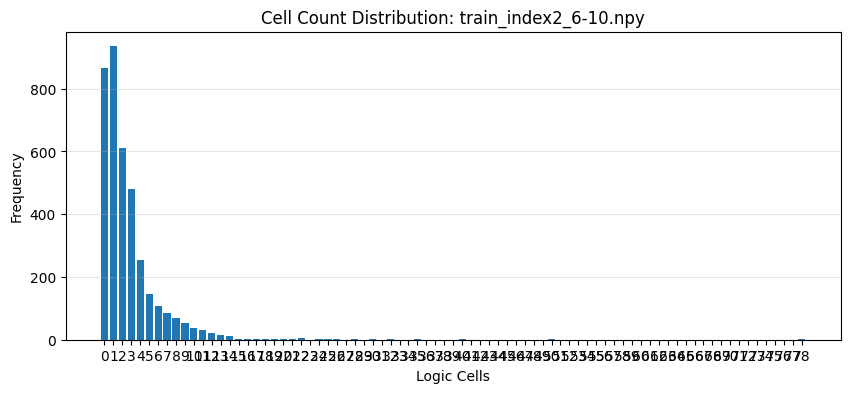

In [5]:
# 4. Check the 6-10 group
if 'train_index2_6-10.npy' in index_files:
    df_6_10 = verify_index_file('train_index2_6-10.npy')
elif 'train_index2_6_10.npy' in index_files:
    df_6_10 = verify_index_file('train_index2_6_10.npy')
else:
    print("Target index file not found!")

In [6]:
# 5. Check actual data content for row 0 of the selection
if 'df_6_10' in locals():
    print("Example samples from the selected dataset:")
    for i in range(5):
        global_idx = df_6_10.iloc[i]['idx']
        print(f"\nSample {i} (Global index {global_idx}):")
        print(f"Description: {dataset[int(global_idx)]['description'][:100]}...")
        print(f"Actual Cells: {df_6_10.iloc[i]['cells']}")

Example samples from the selected dataset:

Sample 0 (Global index 147.0):
Description: {"description": "The Verilog code defines a simple NOT gate, where the output (`out`) is the logical...
Actual Cells: 1.0

Sample 1 (Global index 509.0):
Description: {"description": "The Verilog code defines a module that takes a single input `a` and directly assign...
Actual Cells: nan

Sample 2 (Global index 705.0):
Description: {"description": "This Verilog code defines a 32-bit not gate module that takes a 32-bit input `a` an...
Actual Cells: 1.0

Sample 3 (Global index 977.0):
Description: {"description": "This Verilog code defines a module that converts a 4-bit binary number (`in`) to it...
Actual Cells: 1.0

Sample 4 (Global index 1087.0):
Description: {"description": "The Verilog code defines a left shifter module that takes an input vector `x` of wi...
Actual Cells: 1.0
